In [1]:
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


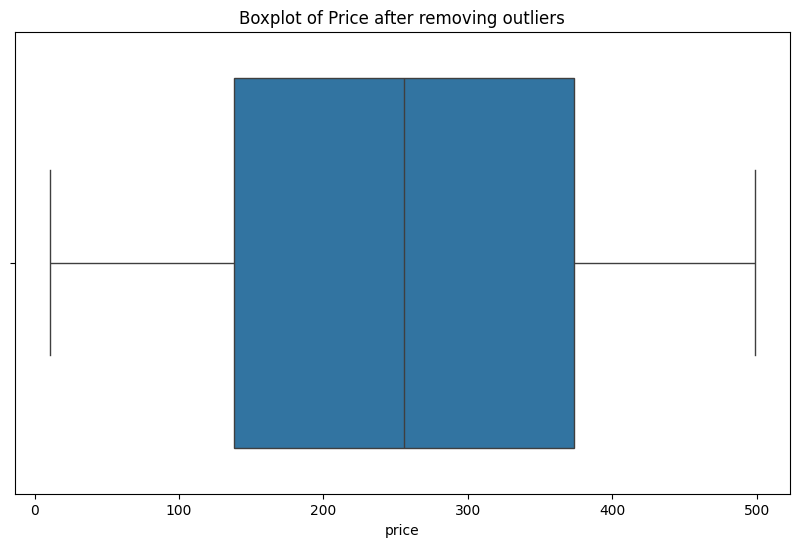

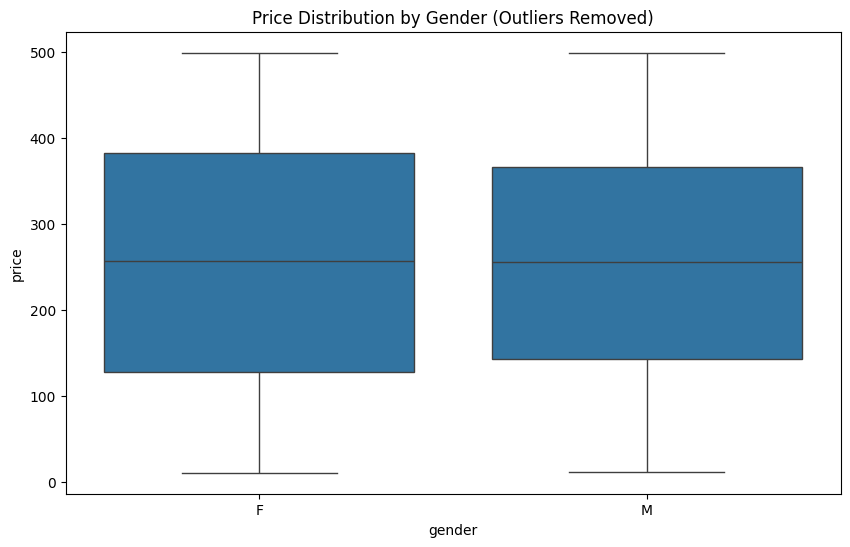

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Use a raw string for the file path to avoid SyntaxWarning
df = pd.read_csv('C:\\Users\\ASUS\\Downloads\\my-market-app-Library_Management_System\\data\\cleaned_data.csv')
# Check if 'order_date' column exists before processing
if 'order_date' in df.columns:
    df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')
    date_included = True
else:
    print("Warning: 'order_date' column not found in the data. Skipping date conversion and related NA drop.")
    date_included = False

# Only use numeric columns that exist in the DataFrame
all_numeric_cols = ['quantity', 'price', 'review_score', 'age']
numeric_cols = [col for col in all_numeric_cols if col in df.columns]
if not numeric_cols:
    print("Warning: None of the expected numeric columns found in the data. Skipping numeric processing.")

else:
    df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

    # Drop NA for date if present, otherwise just numeric columns
    if date_included:
        df = df.dropna(subset=['order_date'] + numeric_cols)
    else:
        df = df.dropna(subset=numeric_cols)

    def remove_outliers(df, column):
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

    for col in numeric_cols:
        df = remove_outliers(df, col)

    plt.figure(figsize=(10, 6))
    if 'price' in df.columns:
        sns.boxplot(x='price', data=df)
        plt.title('Boxplot of Price after removing outliers')
        plt.show()
    else:
        print("Warning: 'price' column not found. Skipping boxplot.")

    plt.figure(figsize=(10, 6))
    if 'gender' in df.columns and 'price' in df.columns:
        sns.boxplot(x='gender', y='price', data=df)
        plt.title('Price Distribution by Gender (Outliers Removed)')
        plt.show()
    else:
        print("Warning: 'gender' or 'price' column not found. Skipping gender boxplot.")
